In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from tradeModul.analysis import show_basic_info,evaluate_model, plot_predictions_and_table
from tradeModul.csv_loader import load_data, save_data
from ta.momentum import RSIIndicator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Conv1D,Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Увеличить максимальное количество отображаемых столбцов
pd.set_option('display.max_columns', None)  # или число, например 50
# Увеличить ширину строки вывода
pd.set_option('display.width', 1000)
# Увеличить максимальное количество символов в ячейке
pd.set_option('display.max_colwidth', None)

# Параметры
FILE_PATH = 'btc_4h_history.csv'
WINDOW = 150
skip = 5000
H = 1  # прогноз на 1 шаг вперёд (4 часа)
TEST_LAST_N = 150

# Фиксируем random seed для воспроизводимости
np.random.seed(78)
tf.random.set_seed(78)

2025-10-16 14:46:56.930245: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-16 14:46:57.135744: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 14:47:01.745372: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# point 1
data_len = len(pd.read_csv(FILE_PATH))
df = pd.read_csv(FILE_PATH, skiprows=range(1, 1 + (data_len - skip)))
# df = pd.read_csv(FILE_PATH)

# print("Размер данных: " + str(len(df)))
print(f"Начальная форма: {df.shape}")
print("Первые 3 свечи:")
print(df[["Open_datetime","Close_datetime", "Open", "Close", "Open_datetime_local", "Close_datetime_local"]].head(3))

print("Последние 3 свечи:")
print(df[["Open_datetime","Close_datetime", "Open", "Close", "Open_datetime_local", "Close_datetime_local"]].tail(3))

show_basic_info(df)

df['datetime'] = pd.to_datetime(df['Close_datetime'])
df.set_index('datetime', inplace=True)


# Подготовка признаков
# EMA5 - 'Экспоненциальная Скользящая Средняя' с периодом 5
# EMA14 - 'Экспоненциальная Скользящая Средняя' с периодом 14
# EMA50 - 'Экспоненциальная Скользящая Средняя' с периодом 50
# EMA14 - 'Индекс относительной силы' с периодом 14

df['EMA5'] = df['Close'].ewm(span=5).mean()
df['EMA14'] = df['Close'].ewm(span=14).mean()
df['EMA50'] = df['Close'].ewm(span=50).mean()
rsi_indicator = RSIIndicator(close=df['Close'], window=14)
df['RSI14'] = rsi_indicator.rsi()
# Удаление строк с NaN
df.dropna(inplace=True)


features_target = ['Close']
features = ['EMA5','EMA14', 'EMA50', 'RSI14']
# features = ['EMA5','EMA14', 'EMA50', 'RSI14']
# features = ['Close', 'EMA14', 'EMA50', 'RSI14']
# features = ['Close', 'EMA14', 'EMA50']
# features = ['EMA14', 'EMA50']
# features = ['Close']
# features = ['RSI14']
data = df[features].values
target = df[features_target].values

print(f"\n Форма после добавления признаков: {df[features + features_target].values.shape}")


Начальная форма: (5000, 16)
Первые 3 свечи:
      Open_datetime    Close_datetime      Open     Close Open_datetime_local Close_datetime_local
0  2023-06-30 08:00  2023-06-30 11:59  30765.10  30910.01    2023-06-30 11:00     2023-06-30 14:59
1  2023-06-30 12:00  2023-06-30 15:59  30910.01  30067.72    2023-06-30 15:00     2023-06-30 18:59
2  2023-06-30 16:00  2023-06-30 19:59  30067.72  30372.36    2023-06-30 19:00     2023-06-30 22:59
Последние 3 свечи:
         Open_datetime    Close_datetime       Open      Close Open_datetime_local Close_datetime_local
4997  2025-10-10 04:00  2025-10-10 07:59  121026.00  120932.05    2025-10-10 07:00     2025-10-10 10:59
4998  2025-10-10 08:00  2025-10-10 11:59  120932.05  121554.55    2025-10-10 11:00     2025-10-10 14:59
4999  2025-10-10 12:00  2025-10-10 15:59  121554.55  119018.98    2025-10-10 15:00     2025-10-10 18:59

ФОРМА И ТИПЫ ДАННЫХ
Форма данных (строк, столбцов): (5000, 16)
Имена столбцов: ['Open time', 'Open', 'High', 'Low', 'Close',

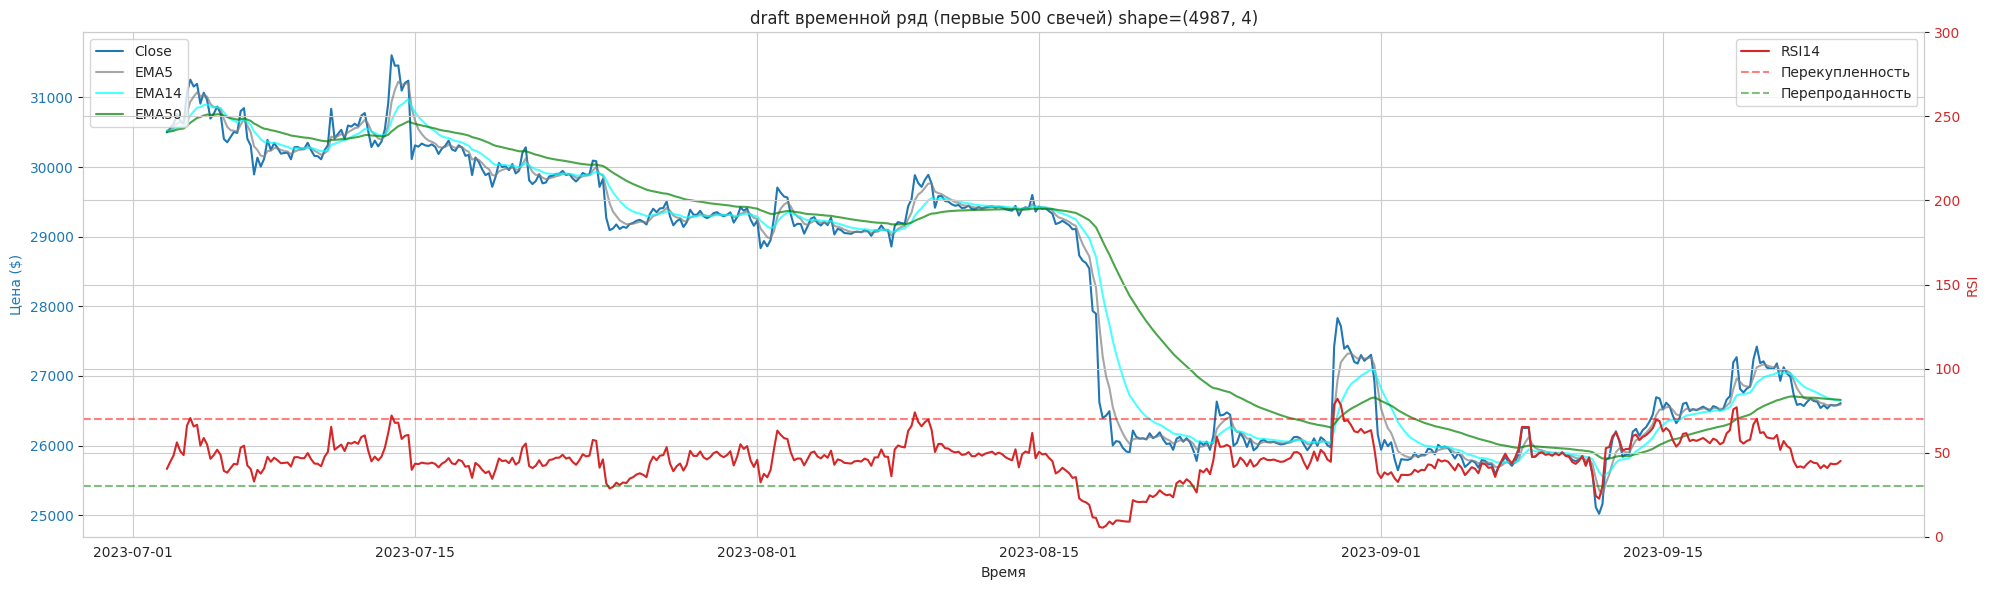

In [3]:
df_plot = df.iloc[:500]

fig, ax1 = plt.subplots(figsize=(20, 6))

# === Левая ось: цена и EMA ===
color = 'tab:blue'
ax1.set_xlabel('Время')
ax1.set_ylabel('Цена ($)', color=color)
ax1.plot(df_plot.index, df_plot['Close'], color=color, label='Close')

if 'EMA5' in df_plot.columns:
    ax1.plot(df_plot.index, df_plot['EMA5'], color='gray', alpha=0.7, label='EMA5')
if 'EMA14' in df_plot.columns:
    ax1.plot(df_plot.index, df_plot['EMA14'], color='cyan', alpha=0.7, label='EMA14')
if 'EMA50' in df_plot.columns:
    ax1.plot(df_plot.index, df_plot['EMA50'], color='green', alpha=0.7, label='EMA50')

ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

if 'RSI14' in df_plot.columns and 'RSI14' in features:
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('RSI', color=color)
    ax2.plot(df_plot.index, df_plot['RSI14'], color=color, label='RSI14')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0, 300)
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Перекупленность')
    ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Перепроданность')
    ax2.legend(loc='upper right')

plt.title(f"draft временной ряд (первые 500 свечей) shape={data.shape}")
plt.tight_layout()
plt.show()

In [4]:
# Создание окон
X, y, r = [], [], []
for i in range(WINDOW, len(data) - H + 1):
    window = data[i - WINDOW:i]
    base_close = window[0][0]
    target_close = target[i + H - 1]
    
    # относительные изменения внутри окна
    rel_window = (window - base_close) / base_close
    X.append(rel_window)
    rel_target = (target_close - base_close) / base_close
    y.append(rel_target)
    r.append(base_close)
    
X = np.array(X)
y = np.array(y)
r = np.array(r)

n_samples, n_timesteps, n_features = X.shape

X_train = X[:-TEST_LAST_N]
X_test = X[-TEST_LAST_N:]
y_train = y[:-TEST_LAST_N]
y_test = y[-TEST_LAST_N:]
r_test = r[-TEST_LAST_N:]

# Получаем соответствующие даты для тестовых примеров
test_dates = df.index[WINDOW + H - 1:][len(y_train):]  

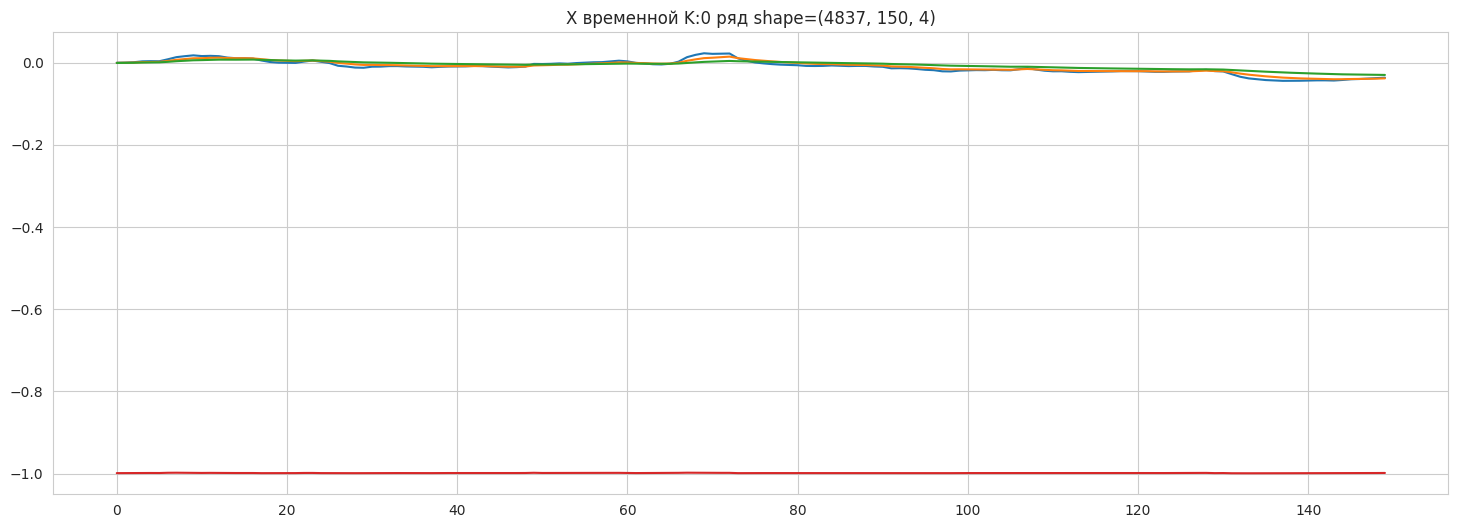

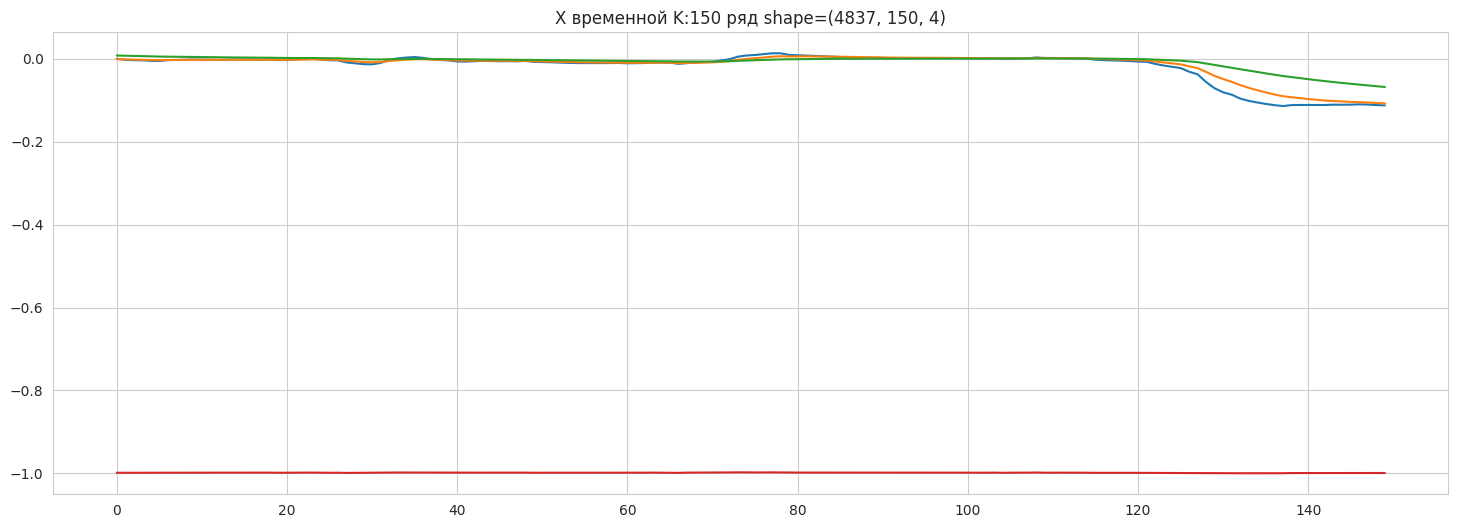

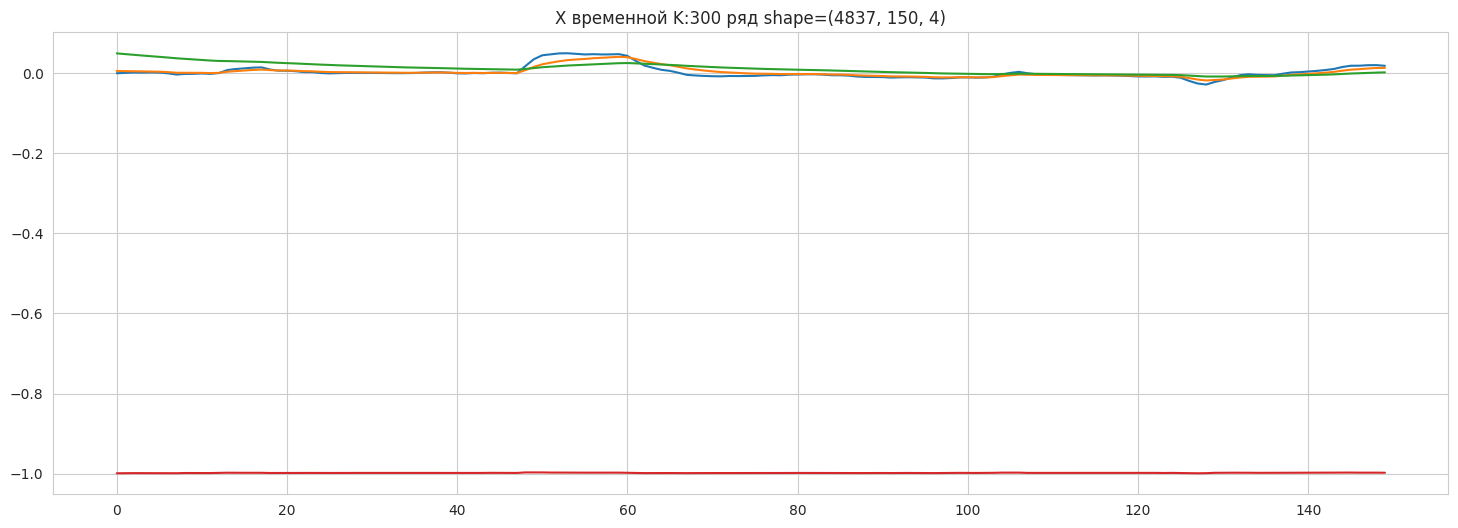

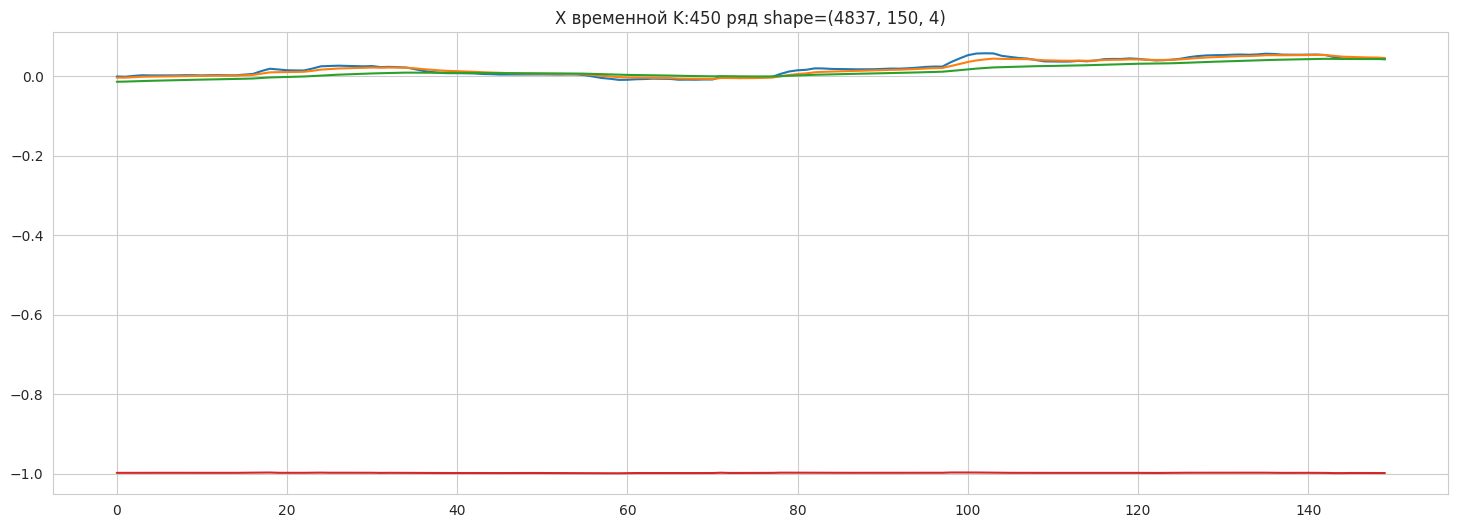

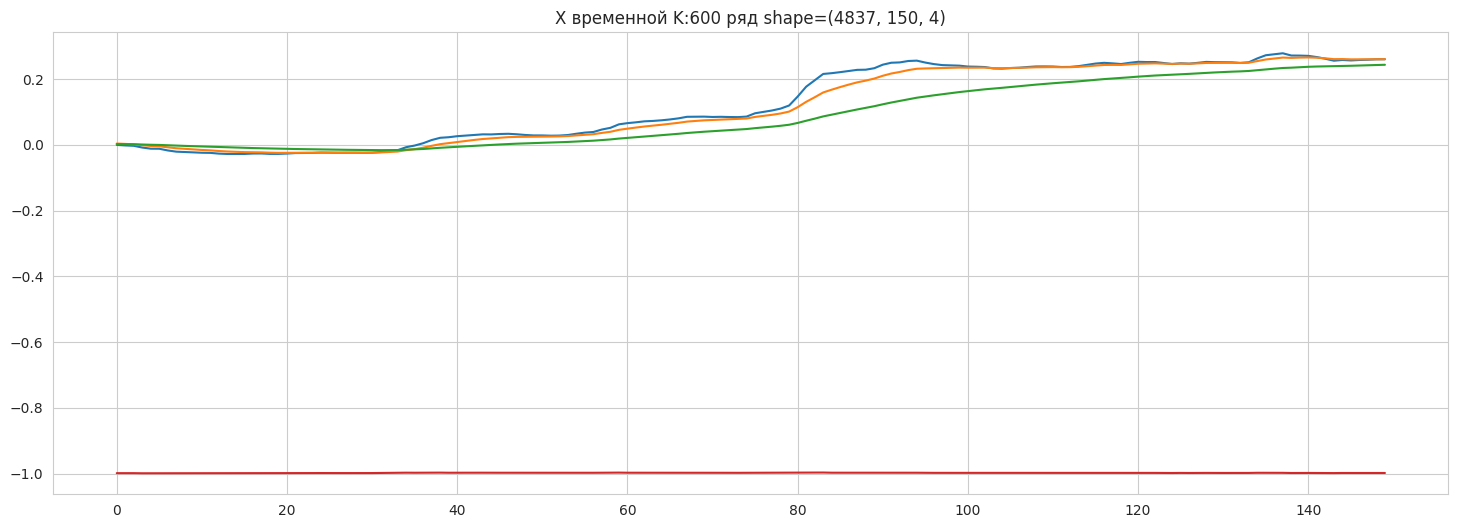

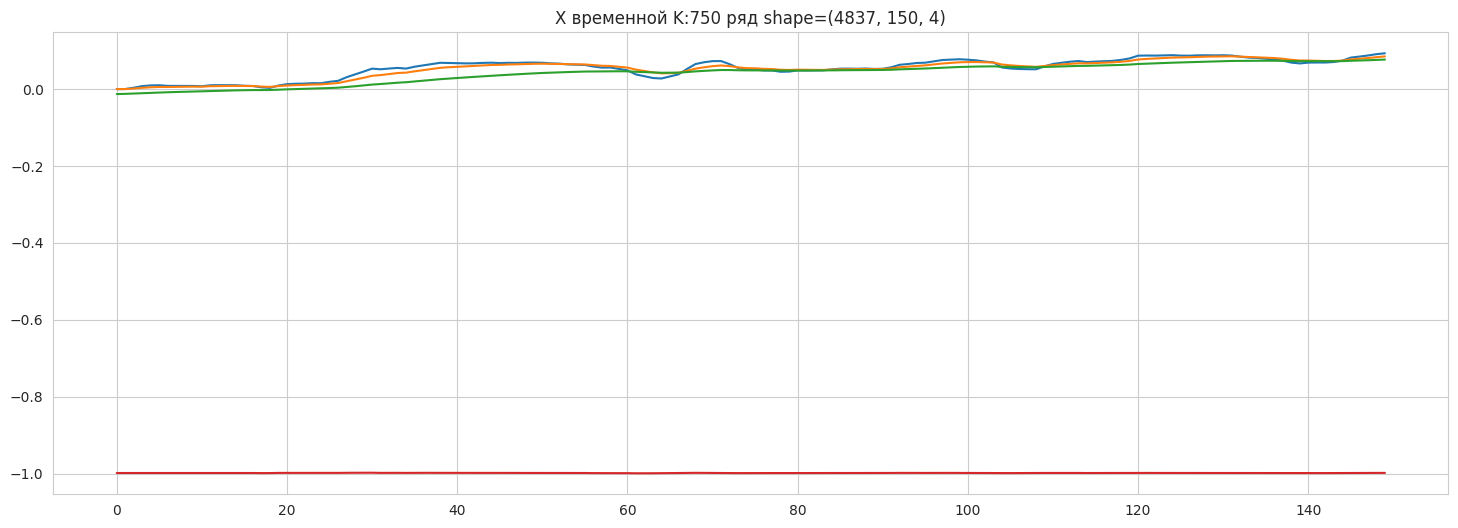

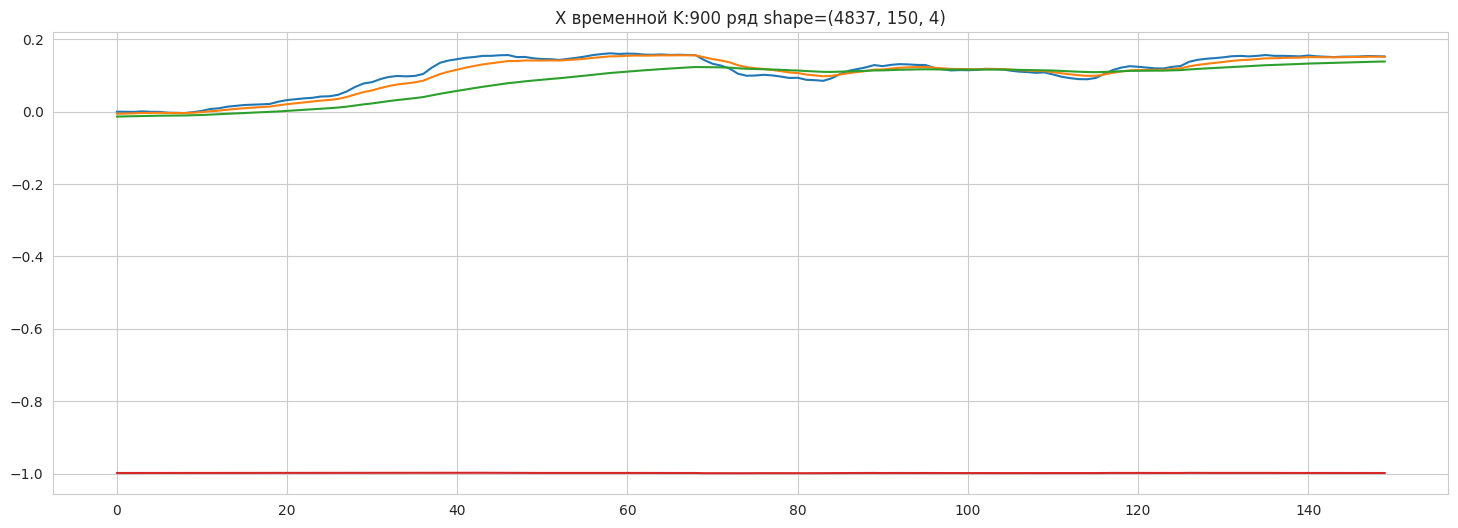

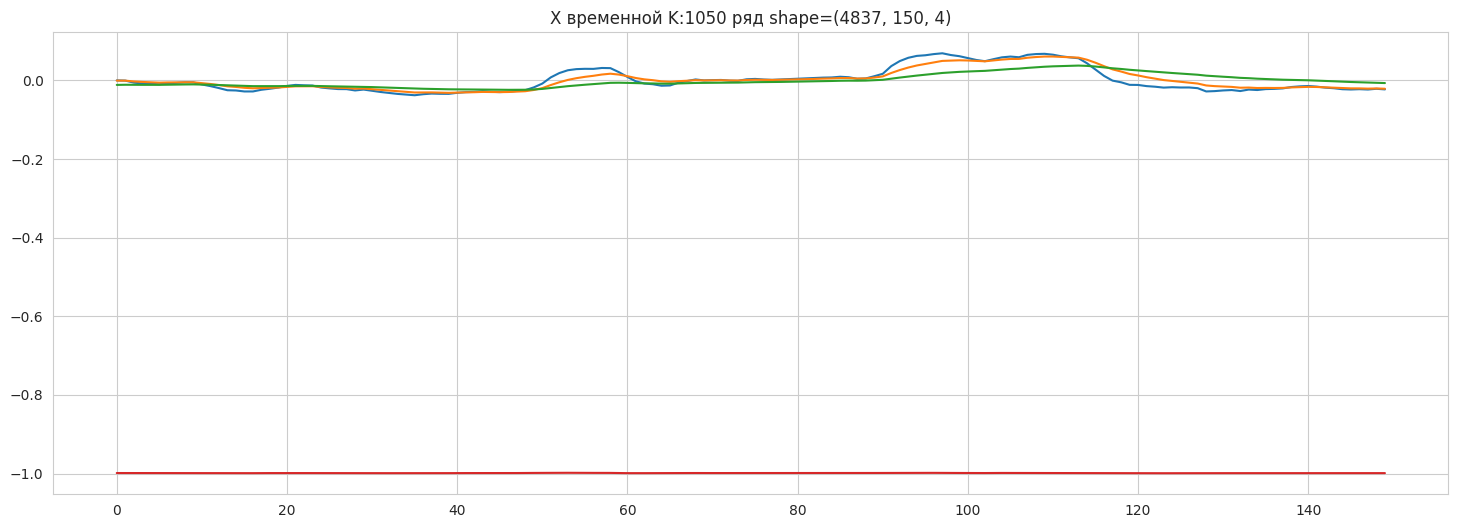

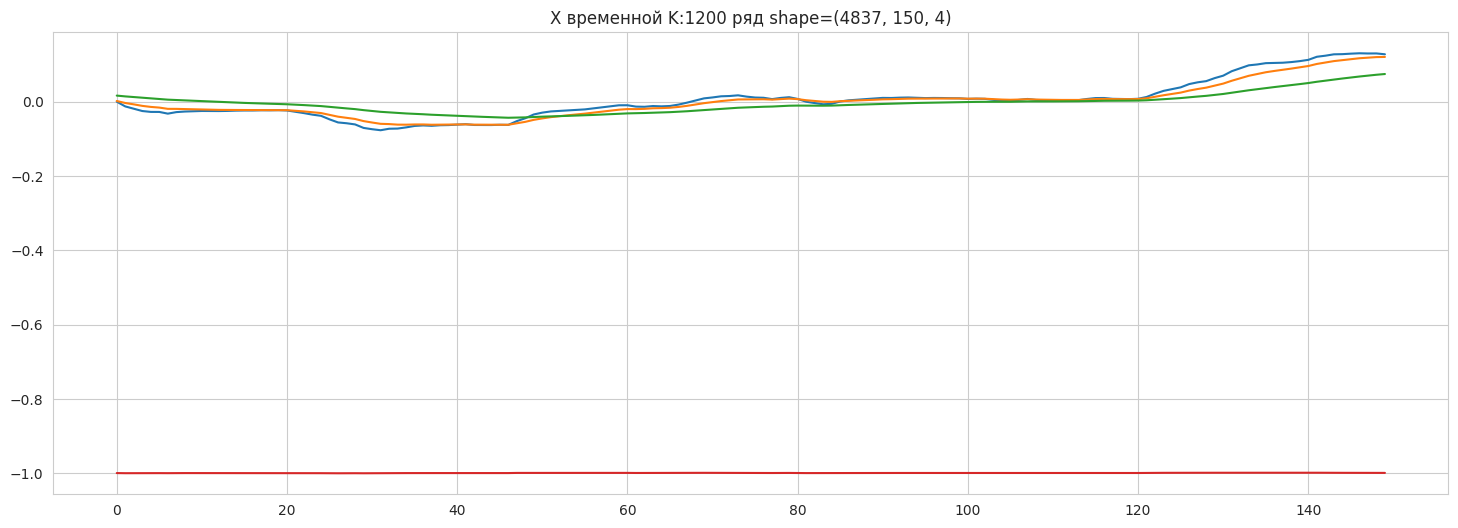

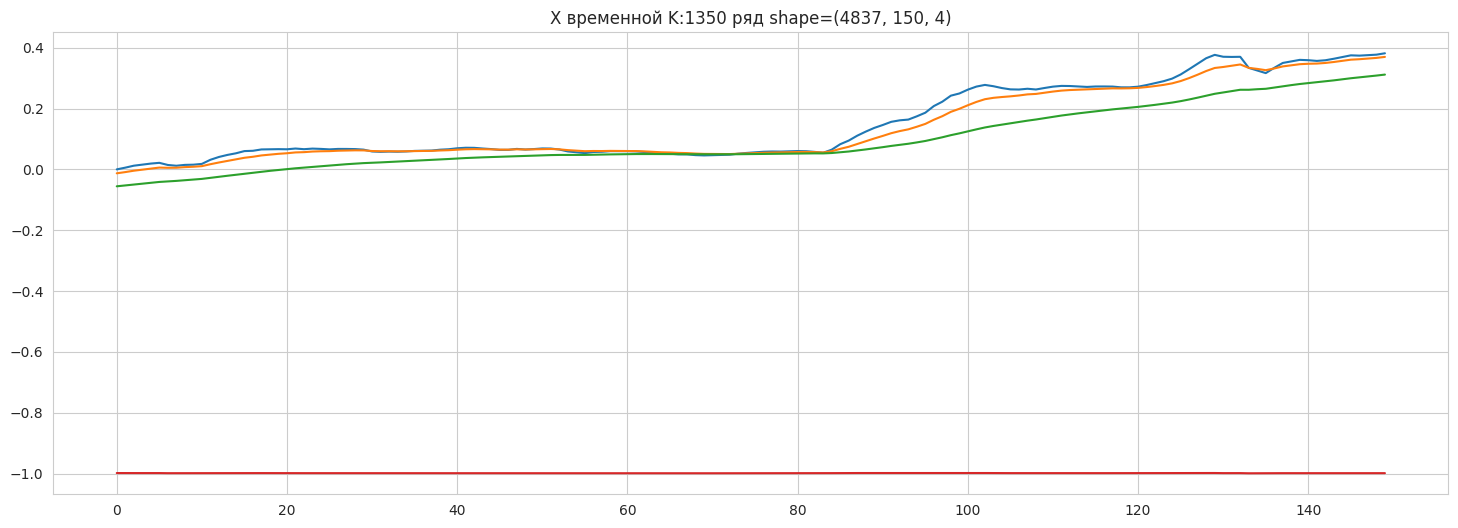

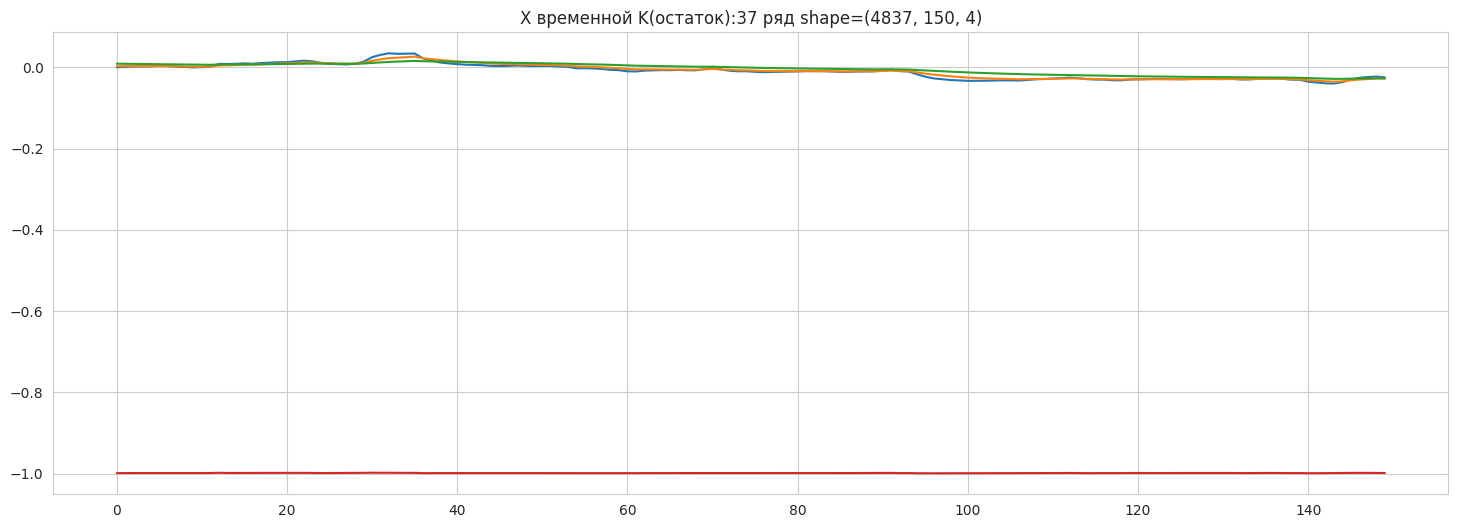

In [5]:
# Визуализация  
max_plot = 10
for k in range(0, len(X) if len(X) <= WINDOW * max_plot else WINDOW * max_plot, WINDOW):
    plt.figure(figsize=(18, 6))
    plt.plot(X[k])
    # plt.plot(y[:300])
    plt.title(f"X временной K:{k} ряд shape={X.shape}")
    plt.show()
plt.figure(figsize=(18, 6))
plt.plot(X[len(X) % WINDOW])
# plt.plot(y[:300])
plt.title(f"X временной K(остаток):{len(X) % WINDOW} ряд shape={X.shape}")
plt.show()   



Обучение обычной модели LSTM...
Epoch 1/50


2025-10-16 14:47:11.263395: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 0.0370
Epoch 2/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - loss: 0.0029
Epoch 3/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 6.1749e-04
Epoch 4/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 5.7703e-04
Epoch 5/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 5.6506e-04
Epoch 6/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 5.5525e-04
Epoch 7/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - loss: 5.5041e-04
Epoch 8/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 5.4237e-04
Epoch 9/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - loss: 5.4324e-04
Epoch 10/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 5.3877e-04
Epoch 11/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - loss: 5.3639e-04
Epoch 12/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 5.3003e-04
Epoch 13/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 5.2287e-04
Epoch 14/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - loss: 5.1

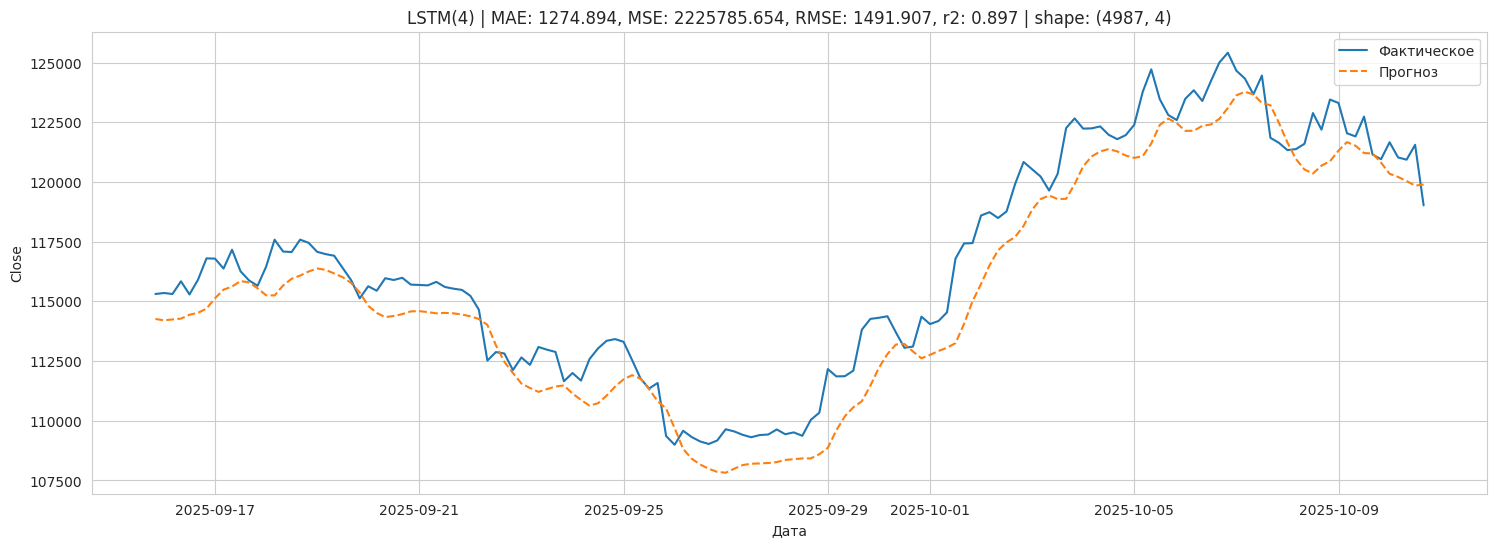

In [6]:
print("Обучение обычной модели LSTM...")

units = n_features
model = Sequential([
    LSTM(units, activation='relu', input_shape=(WINDOW, n_features)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='loss',
    patience=7,
    min_delta=1e-6,
    verbose=1,
    restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

y_pred_inv = (r_test * (1 + y_pred.ravel()))
y_test_inv = (r_test * (1 + y_test.ravel()))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"r2 Score: {r2:.3f}")

plt.figure(figsize=(18, 6))
plt.plot(test_dates, y_test_inv, label='Фактическое')
plt.plot(test_dates, y_pred_inv, label='Прогноз', linestyle='--')
plt.title(f"LSTM({units}) | MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, r2: {r2:.3f} | shape: {data.shape}")
plt.xlabel("Дата")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
print("Обучение модели LSTM + anti_naive_loss...")

def anti_naive_loss(alpha=0.3, n_lags=3):
    def loss(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        total_penalty = 0.0
        batch_size = tf.shape(y_true)[0]
        for lag in range(1, n_lags + 1):
            shifted = tf.roll(y_true, shift=lag, axis=0)
            penalty = tf.reduce_mean(tf.square(y_pred - shifted))
            total_penalty += penalty
            
        avg_penalty = total_penalty / n_lags
        
        return mse + alpha * avg_penalty
    
    return loss

units = n_features
model = Sequential([
    LSTM(units, activation='relu', input_shape=(WINDOW, n_features)),
    Dense(1)
])

model.compile(
    optimizer='adam',  
    loss=anti_naive_loss(alpha=0.3, n_lags=3),
    metrics=[direction_accuracy]
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=7,
    min_delta=1e-6,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
    shuffle=False 
)

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

y_pred_inv = (r_test * (1 + y_pred.ravel()))
y_test_inv = (r_test * (1 + y_test.ravel()))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"r2 Score: {r2:.3f}")

plt.figure(figsize=(18, 6))
plt.plot(test_dates, y_test_inv, label='Фактическое')
plt.plot(test_dates, y_pred_inv, label='Прогноз', linestyle='--')
plt.title(f"LSTM({units}) + anti_naive_loss | MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, r2: {r2:.3f} | shape: {data.shape}")
plt.xlabel("Дата")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.show()

Обучение модели LSTM + anti_naive_loss...


/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NameError: name 'direction_accuracy' is not defined

In [ ]:
from sklearn.linear_model import HuberRegressor

# Преобразуем 3D в 2D
n_samples, WINDOW, n_features = X_train.shape

X_train_flat = X_train.reshape(n_samples, WINDOW * n_features)
X_test_flat = X_test.reshape(X_test.shape[0], WINDOW * n_features)

print("Обучение HuberRegressor...")

huber = HuberRegressor(
    alpha=0.0001,        # L2-регуляризация
    epsilon=1.35,        
    fit_intercept=True,
    max_iter=60,
    tol=1e-05,
    warm_start=False
)

huber.fit(X_train_flat, y_train)

y_pred = huber.predict(X_test_flat)

y_pred_inv = r_test * (1 + y_pred.ravel())
y_test_inv = r_test * (1 + y_test.ravel())

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R²: {r2:.3f}")

plt.figure(figsize=(18, 6))
plt.plot(test_dates, y_test_inv, label='Фактическое', marker='o', markersize=3)
plt.plot(test_dates, y_pred_inv, label='Прогноз', linestyle='--')
plt.title(f"HuberRegressor | MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

n_samples, WINDOW, n_features = X_train.shape

X_train_flat = X_train.reshape(n_samples, WINDOW * n_features)
X_test_flat = X_test.reshape(X_test.shape[0], WINDOW * n_features)

print("Обучение GradientBoostingRegressor...")

gbr = GradientBoostingRegressor(
    n_estimators=100,        
    learning_rate=0.1,       
    max_depth=3,             
    subsample=1.0,           
    criterion='squared_error',  
    random_state=78,
    loss='squared_error'     
)

gbr.fit(X_train_flat, y_train)

y_pred = gbr.predict(X_test_flat)

y_pred_inv = r_test * (1 + y_pred.ravel())
y_test_inv = r_test * (1 + y_test.ravel())

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R²: {r2:.3f}")

plt.figure(figsize=(18, 6))
plt.plot(test_dates, y_test_inv, label='Фактическое', marker='o', markersize=3)
plt.plot(test_dates, y_pred_inv, label='Прогноз', linestyle='--')
plt.title(f"GradientBoostingRegressor | MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# Подготовка данных (предполагается, что X_train, X_test, y_train, y_test, r_test, test_dates уже созданы)
# -------------------------------

n_samples, WINDOW, n_features = X_train.shape

# Преобразуем в 2D 
X_train_flat = X_train.reshape(n_samples, WINDOW * n_features)
X_test_flat = X_test.reshape(X_test.shape[0], WINDOW * n_features)

predictions = {}

print("Обучение LSTM...")
units = n_features * n_features
model_lstm = Sequential([
    LSTM(units, activation='relu', input_shape=(WINDOW, n_features)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(
    monitor='loss',
    patience=7,
    min_delta=1e-6,
    verbose=0,
    restore_best_weights=True
)
model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
    shuffle=False
)
y_pred_lstm = model_lstm.predict(X_test, verbose=0).flatten()
predictions['LSTM'] = y_pred_lstm

print("Обучение HuberRegressor...")
huber = HuberRegressor(
    alpha=0.0001,
    epsilon=1.35,
    fit_intercept=True,
    max_iter=100,
    tol=1e-05
)
huber.fit(X_train_flat, y_train)
y_pred_huber = huber.predict(X_test_flat)
predictions['Huber'] = y_pred_huber

print("Обучение GradientBoostingRegressor...")
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train_flat, y_train)
y_pred_gbr = gbr.predict(X_test_flat)
predictions['GBR'] = y_pred_gbr

# Ансамбль: простое усреднение
y_pred_ensemble = np.mean([
    predictions['LSTM'],
    predictions['Huber'],
    predictions['GBR']
], axis=0)
predictions['Ensemble'] = y_pred_ensemble

results = {}

# Оценка и визуализация для каждой модели + ансамбля
for name, y_pred in predictions.items():
    y_pred_inv = r_test * (1 + y_pred.ravel())
    y_test_inv = r_test * (1 + y_test.ravel())
    
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inv, y_pred_inv)
    
    results[name] = {
        'y_pred_inv': y_pred_inv,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    }
    
    # Визуализация
    plt.figure(figsize=(18, 6))
    plt.plot(test_dates, y_test_inv, label='Фактическое', marker='o', markersize=3)
    plt.plot(test_dates, y_pred_inv, label=f'Прогноз ({name})', linestyle='--')
    plt.title(f"{name} | MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")
    plt.xlabel("Дата")
    plt.ylabel("Цена закрытия ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)
for name, res in results.items():
    print(f"{name:12} → MAE: {res['mae']:.3f} | RMSE: {res['rmse']:.3f} | R²: {res['r2']:.4f}")

best_model = min(results.items(), key=lambda x: x[1]['mae'])
print(f"\n Лучшая модель по MAE: {best_model[0]} (MAE = {best_model[1]['mae']:.3f})")

In [ ]:
# Поиск аномалий
from sklearn.ensemble import IsolationForest

# Используем исходный ряд (абсолютные значения Close)
close_prices = df['Close'].values  # или y_test_inv, если работаете только с тестом
close_prices = df['EMA50'].values  # или y_test_inv, если работаете только с тестом
close_prices = df['RSI14'].values  # или y_test_inv, если работаете только с тестом


dates_for_anomaly = df.index      

# Статистический метод: Z-score с окном
WINDOW_ANOM = WINDOW  # размер окна для локальной статистики
z_scores = np.zeros_like(close_prices)
anomalies_z = np.zeros_like(close_prices, dtype=bool)

for i in range(WINDOW_ANOM, len(close_prices)):
    window = close_prices[i - WINDOW_ANOM:i]
    mean = np.mean(window)
    std = np.std(window)
    if std == 0:
        z = 0
    else:
        z = (close_prices[i] - mean) / std
    z_scores[i] = z
    anomalies_z[i] = abs(z) > 3  

# 2. Isolation Forest
# Создаём признаки: лаги и изменения
lags = [1, 2, 3, 5, 10]
features_anom = []
for lag in lags:
    features_anom.append(np.roll(close_prices, lag))
features_anom = np.column_stack(features_anom)
features_anom[:max(lags)] = 0  

# Обучаем Isolation Forest
iso_forest = IsolationForest(
    contamination=0.03,  # ожидаем 3% аномалий
    random_state=42,
    n_estimators=100
)
anomaly_labels = iso_forest.fit_predict(features_anom)
anomalies_iso = anomaly_labels == -1  # -1 = аномалия

# График 1: Z-score
plt.figure(figsize=(18, 6))
plt.plot(dates_for_anomaly, close_prices, label='Цена закрытия', color='blue')
plt.scatter(
    dates_for_anomaly[anomalies_z],
    close_prices[anomalies_z],
    color='red', label='Аномалии (Z-score)', s=50, zorder=5
)
plt.title("Аномалии: Z-score (окно=50)")
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График 2: Isolation Forest
plt.figure(figsize=(18, 6))
plt.plot(dates_for_anomaly, close_prices, label='Цена закрытия', color='blue')
plt.scatter(
    dates_for_anomaly[anomalies_iso],
    close_prices[anomalies_iso],
    color='orange', label='Аномалии (Isolation Forest)', s=50, zorder=5
)
plt.title("Аномалии: Isolation Forest")
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График 3: Объединённые аномалии (логическое ИЛИ)
anomalies_combined = anomalies_z | anomalies_iso
plt.figure(figsize=(18, 6))
plt.plot(dates_for_anomaly, close_prices, label='Цена закрытия', color='blue')
plt.scatter(
    dates_for_anomaly[anomalies_combined],
    close_prices[anomalies_combined],
    color='purple', label='Аномалии (объединённые)', s=50, zorder=5
)
plt.title("Аномалии: объединённый результат")
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ОБНАРУЖЕНИЕ АНОМАЛИЙ")
print("="*50)
print(f"Всего точек: {len(close_prices)}")
print(f"Аномалий (Z-score): {anomalies_z.sum()} ({anomalies_z.mean()*100:.2f}%)")
print(f"Аномалий (Isolation Forest): {anomalies_iso.sum()} ({anomalies_iso.mean()*100:.2f}%)")
print(f"Объединённых аномалий: {anomalies_combined.sum()} ({anomalies_combined.mean()*100:.2f}%)")

In [ ]:
from pycaret.regression import *

# columns = features ['Close', 'EMA14', 'EMA50', 'RSI14']
df = pd.DataFrame(data, columns=features)

train_data = df.iloc[:-TEST_LAST_N]
test_data = df.iloc[-TEST_LAST_N:]


clf = setup(
    data=train_data,           
    target='Close',
    session_id=123,
    train_size=0.85,            
    fold=3,
    data_split_shuffle=False,     
    fold_shuffle=False,           
    numeric_imputation='mean'
)

best_model = compare_models(sort='MAE', n_select=1)
print(best_model)
evaluate_model(best_model)
final_model = finalize_model(best_model)

# Прогноз на тестовых данных
y_pred = predict_model(final_model, data=test_data)
y_pred_values = y_pred['prediction_label'].values  
y_test_values = test_data['Close'].values

mae = mean_absolute_error(y_test_values, y_pred_values)
mse = mean_squared_error(y_test_values, y_pred_values)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_values, y_pred_values)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

plt.figure(figsize=(18, 6))
plt.plot(test_data.index, y_test_values, label='Фактическое', marker='o', markersize=3)
plt.plot(test_data.index, y_pred_values, label='Прогноз (PyCaret)', linestyle='--')
plt.title(f"PyCaret Regression | MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия ($)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage


n_samples, n_timesteps, n_features = X.shape
X_flat = X.reshape(n_samples, n_timesteps * n_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

inertia_scores = []
k_values = range(1, 42)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_flat)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.show()


# Применение агломеративной кластеризации
n_clusters = 10  

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
predicted_labels = agg_clustering.fit_predict(X_scaled)

# Снижение размерности с использованием PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Визуализация кластеров после агломеративной кластеризации
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predicted_labels, s=50, cmap='viridis')
plt.title("Agglomerative Clustering (Digits)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Визуализация дендрограммы
plt.figure(figsize=(10, 7))
Z = linkage(X_scaled, method='ward') 
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()

silhouette_avg = silhouette_score(X_scaled, predicted_labels)
davies_bouldin = davies_bouldin_score(X_scaled, predicted_labels)
calinski_harabasz = calinski_harabasz_score(X_scaled, predicted_labels)

print(f"Силуэтовская оценка: {silhouette_avg:.2f}")
print(f"Индекс Дэвиса-Болдуина: {davies_bouldin:.2f}")
print(f"Индекс Калински-Харабаса: {calinski_harabasz:.2f}")